Administration Thematic Area

In [ ]:
# license reassign
# assert statements -> value, instance
# don't hardcode anything
# import timer -> time
# datastores - SQL server,
# across all OS/platform - Kubernetes, enterprise
# available credits - agol
# retreive server and portal logs - enterprise 
# health check
# run the notebooks on each authentication 
# install setup - test
# document everything in confluence wiki - something like the following
# https://confluencewikidev.esri.com/pages/viewpage.action?pageId=162365974

In [ ]:
# product executed on -> Pro, local, Notebook Server
# environment run against - Enterprise, AGOL, Kubernetes
# OS -> Windows, Linux
# authentication schemes -> IWA, PKI, LDAP

In [90]:
from arcgis.gis import GIS, Item
import uuid
from arcgis.gis.admin import PortalAdminManager, AGOLAdminManager, License, LicenseManager, CreditManager

In [9]:
from arcgis.gis import User, RoleManager, Group, Role

In [148]:
from arcgis.gis.clone import CloningJob

In [ ]:
# notebook currently ran with AGOL and profile
# next - enterprise and profile

In [ ]:
# authenticate with IWA, PKI, LDAP

In [3]:
profile_names = [
    "your_online_admin_profile",
    "your_ent_admin_profile"
]

In [20]:
# PKI authentication
gis = GIS(
            url="https://rqawinpki03pt.ags.esri.com/gis",
            cert_file="./datasets_and_certs/creator2.pfx",
            password="portalaccount1",
            verify_cert=False,
        )

Setting `verify_cert` to False is a security risk, use at your own risk.


In [17]:
# only runs on windows, and the user should be admin
gis1 = GIS(url="https://rqawiniwa02pt.ags.esri.com/gis", verify_cert=False)

Setting `verify_cert` to False is a security risk, use at your own risk.


In [91]:
gis1 = GIS(profile="your_ent_admin_profile")

In [65]:
gis1 = GIS(profile="your_online_admin_profile")

In [21]:
my_user = gis1.users.me

In [10]:
assert isinstance(my_user, User)

In [88]:
# Test if the logged in user is Administrator or not - credits-John

assert gis1.users.me.role == "org_admin"
assert gis1.admin
assert "portal:admin:inviteUsers" in gis1.users.me.privileges
assert "portal:admin:deleteUsers" in gis1.users.me.privileges
assert "portal:admin:manageLicenses" in gis1.users.me.privileges

In [93]:
# create a new user in the organization - there is no error/nor successful if we create the same user again
username_suffix = str(uuid.uuid4())[:4]
new_user = gis1.users.create(username = "test_create_"+ username_suffix, password = "S8V3*t4L8tr!&@!", firstname="Test", lastname="User 1", email="tkukreja@esri.com", description="Test user creation.", user_type="creatorUT", role="iBBBBBBBBBBBBBBB")

In [94]:
# credits is only available for agol
if gis1._is_agol:
    cm = gis1.admin.credits
    assert isinstance(cm, CreditManager)
    # get total available credits for the user
    print(cm.credits)
    # get default limit for credits
    assert cm.default_limit == 500
    print(new_user['assignedCredits'])

In [ ]:
# in the following cells
# check licenses of a user
# get a license 
# check if that license is assigned to that user
# if that license is not assigned then assign that license to the user
# verify now if that license is assigned to that user
# unassign the license

In [95]:
# creates a license manager object
license_mgr = gis1.admin.license

In [96]:
assert isinstance(license_mgr, LicenseManager)

In [97]:
# gets the license
# check for a different license - frequent license
# list out the licenses and pick one out of that, 
license = license_mgr.get(name="ArcGIS Navigator")

In [98]:
assert isinstance(license, License)

In [99]:
# gives a list of licenses assigned to the user
license_list_user = license.check(user=new_user.username)
assert isinstance(license_list_user, list)
# navigator role should not be in the list
if gis1.properties.isPortal and not gis1._portal.is_kubernetes:
    assert "navigator" not in license_list_user
if gis1._is_agol:
    assert "Navigator" not in license_list_user

In [100]:
# assigns a license not assigned to the user
# for enterprise-navigator works
if gis1.properties.isPortal and not gis1._portal.is_kubernetes:
    assert license.assign(username=new_user.username, entitlements=["navigator"])
# for agol
if gis1._is_agol:
    assert license.assign(username=new_user.username, entitlements=["Navigator"])

In [101]:
# check now navigator should be there in the license list
if gis1.properties.isPortal and not gis1._portal.is_kubernetes:
    assert "navigator" in license.check(user=new_user.username)
if gis1._is_agol:
    assert "Navigator" in license.check(user=new_user.username)

In [102]:
# unassign the license to the user
if gis1.properties.isPortal and not gis1._portal.is_kubernetes:
    assert license.revoke(username=new_user.username, entitlements=["navigator"])
if gis1._is_agol:
    assert license.revoke(username=new_user.username, entitlements=["Navigator"])

In [103]:
# check if the license is unassigned
if gis1.properties.isPortal and not gis1._portal.is_kubernetes:
    assert "navigator" not in license_list_user
if gis1._is_agol:
    assert "Navigator" not in license_list_user

In [ ]:
# datastore - would only work for Enterprise

In [104]:
# no hardcoding -> add a datastore item to the portal
if gis1.properties.isPortal and not gis1._portal.is_kubernetes:
    datastore_item = gis1.content.get("bf30f0ea2dfa40d595b0453778815a59")
    server_list = gis1.admin.federation.servers
    server = [server for server in server_list["servers"] if server["serverRole"] == "HOSTING_SERVER"][0]
    server_id = server["id"]
    assert gis1.datastore.register(item=datastore_item, server_id=server_id)
    assert gis1.datastore.servers(item=datastore_item.itemid)
    assert gis1.datastore.validate(server_id=server_id, item=datastore_item)
    assert isinstance(gis1.datastore.servers(item=datastore_item), list)

In [105]:
assert isinstance(new_user, User)
assert new_user.username == "test_create_" + username_suffix
# check user_type, role

In [106]:
# test UserManager.user_settings
new_user.user_settings = {'landingPage':{"url":"webmap/viewer.html"}}

In [107]:
assert type(new_user.user_settings) == dict

In [109]:
assert 'landingPage' in new_user.user_settings

In [110]:
# test UserManager.license_types
assert type(gis1.users.license_types) == list

In [111]:
for license in gis1.users.license_types:
    assert 'id' in license

In [112]:
# test UserManager.user_groups -> gives a list of groups user is a part of 
user_groups_list = gis1.users.user_groups([new_user])

In [113]:
assert type(user_groups_list) == list

In [115]:
user_details_list = gis1.users.user_groups([new_user])

In [116]:
if len(user_details_list) > 0:
    for user in user_details_list:
        assert 'groups' in user
        for group in user['groups']:
            assert 'id' in group

In [65]:
# send_notification can only be used with AGOL
# test UserManager.send_notification()

In [117]:
# send_notification only works in AGOL
if gis1._is_agol:
    assert gis1.users.send_notification(users=[new_user], subject="Test notification", message="This message is just to test the notification")

In [118]:
# test UserManager.search()
user_new = gis1.users.search("username:{}".format(new_user.username))[-1]
assert isinstance(user_new, User)
assert user_new.username == new_user.username
# assert something else as well, like role, email


In [119]:
# test UserManager.advanced_search()
orgid = gis1.users.me.orgId
q = f"orgid: {orgid}"
res = gis1.users.advanced_search(query=q, start=3, max_users=10)
assert len(res["results"]) >= 1
assert res["start"] == 3

In [ ]:
# add more in advanced_search

In [120]:
content_manager = gis_agol_non_admin.content
query = f"owner: {gis_agol_non_admin.users.me.username}"
items = content_manager.advanced_search(query)
assert isinstance(items, dict)

In [121]:
# test UserManager.invite()
assert gis1.users.invite(email="tkukreja@esri.com")

In [ ]:
# delete user

In [122]:
assert gis1.users.delete_users(users=[new_user]) == []

In [42]:
# create a role

In [123]:
role_mgr = gis1.users.roles

In [124]:
priviliges = ["portal:publisher:publishFeatures"]

In [125]:
created_role = gis1.users.roles.create(name="custom_role_1_test", 
                        description="creating a custom role for testing", 
                        privileges=priviliges)

In [126]:
assert isinstance(created_role, Role)

In [127]:
# test the priviliges property
listOfPriviliges = created_role.privileges

In [129]:
assert isinstance(listOfPriviliges, list), "listOfPriviliges must be a list"

In [130]:
for i in range(len(listOfPriviliges)):
    assert isinstance(listOfPriviliges[i], str)
    assert priviliges[i] == listOfPriviliges[i]

In [132]:
# replace one privilige instead and run the above peice of code again/change
created_role.privileges = ["portal:user:shareToGroup"]

In [133]:
assert "portal:user:shareToGroup" in created_role.privileges
assert len(created_role.privileges) == 1

In [134]:
# test RoleManager.all() 
roles_list = role_mgr.all()

In [135]:
assert isinstance(roles_list, list), "roles_list must be a list"

In [136]:
for role in roles_list:
    assert isinstance(role, Role)
    assert role.role_id
    assert role.name

In [139]:
# test RoleManager.exists()
assert role_mgr.exists(role_name="custom_role_1_test")

In [140]:
# test RoleManager.get_role()
role_id = ''
role_name = ''
for role in role_mgr.all():
    if "custom_role_1_test" in role.name:
        role_id = role.role_id
        role_name = role.name
        

In [141]:
assert isinstance(role_mgr.get_role(role_id=role_id), Role)
role_fetched = role_mgr.get_role(role_id=role_id)

In [142]:
assert role_fetched.name == role_name
assert role_fetched.role_id == role_id

In [ ]:
# delete a role

In [143]:
for role in role_mgr.all():
    if "custom_role_1_test" in role.name:
        print(f'{role.name}  {role.role_id}')
        assert role.delete()


custom_role_1_test  W4RL3hYLkCDPKQ2D


In [144]:
# the role should not exist anymore in the roles list
for role in role_mgr.all():
    assert role.name != "custom_role_1_test"

In [153]:
# test RoleManager.clone()
cloning_job_list = role_mgr.clone(roles=["Data Editor"])
assert isinstance(cloning_job_list, list)
assert isinstance(cloning_job_list[0], CloningJob)
assert cloning_job_list[0].status == True

In [ ]:
# create a group

In [154]:
group_mgr = gis1.groups

In [155]:
created_group = group_mgr.create(title="test_create_group_3",
                 tags = "test, create group",
                 description = "testing group creation")

In [159]:
# created_group.user_list()

In [157]:
assert isinstance(created_group, Group)
# check owner of group
# default capabilities of group\
# get_members

In [158]:
assert created_group.delete()

In [ ]:
# update a group owned by other organization members

In [162]:
# update the group id

if gis1._is_agol:
    update_group = group_mgr.get(groupid="a996a5c432e845688905febdae9bdc36")
if gis1.properties.isPortal and not gis1._portal.is_kubernetes:

In [163]:
update_group

In [200]:
assert update_group.owner != my_user.username

In [201]:
previous_description = update_group.description

In [106]:
update_group.update(description="Group to share your landmarks")

TypeError: Portal.update_group() got an unexpected keyword argument 'auto_join'

In [ ]:
# delete a group owned by someo other organization member

In [203]:
assert update_group.delete()

In [ ]:
# Item class

In [164]:
recent_earthquakes_item = gis1.content.get("9e2f2b544c954fda9cd13b7f3e6eebce")

<Item title:"Recent Earthquakes" type:Feature Layer Collection owner:esri_livingatlas>
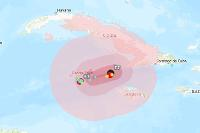

In [165]:
recent_earthquakes_item

In [166]:
# test Item.download() -> returns the path of download
download_path = recent_earthquakes_item.download('.', 'usa_short_term_weather')

In [167]:
assert type(download_path) == str
assert download_path == '.\\usa_short_term_weather'

In [168]:
# test Item.export -> returns an Item
exported_item = recent_earthquakes_item.export(title="usa-weather-warning", export_format="CSV")

Exception: Could not export item: 9e2f2b544c954fda9cd13b7f3e6eebce

In [88]:
assert type(exported_item) == Item

In [92]:
# check export format
assert exported_item.type == 'CSV Collection'

In [117]:
# test Item.publish()
csv_item = gis1.content.get("e65312babe5b4efbaa2842235b79f653")

<Item title:"test_har_dataset" type:CSV owner:api_data_owner>
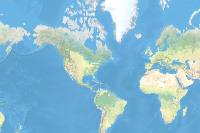

In [119]:
csv_item # find some other item

In [ ]:
published_item = csv_item.publish()

<Item title:"test_har_dataset" type:Table Layer owner:api_data_owner>
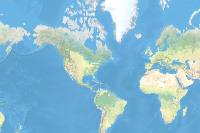

In [18]:
assert type(published_item) == Item
# assert owner
# gis.content.search returns 2 items -> 1 CSV and 1 Hosted Table Layer

In [147]:
assert published_item.delete(permanent=True)

True

In [95]:
returned_data = recent_earthquakes_item.get_data()

In [96]:
data_type = type(returned_data)
assert data_type == dict

In [97]:
assert 'layers' in returned_data